# Future regressors

为了对未来回归量进行建模，必须知道这些回归量的过去值和未来值。因此，与上一节教程中的滞后回归量相比，未来回归量除了历史值外，还具有未来的预测值。

In [2]:
import pandas as pd

# Load the dataset for tutorial 4 with the extra temperature column
df = pd.read_csv('./data/SF_temperature&hospital_load.csv')
df.head()

,ds,y,temperature
0,2015-01-01,64.92,277.00
1,2015-01-02,58.46,277.95
2,2015-01-03,63.35,278.83
3,2015-01-04,50.54,279.64
4,2015-01-05,64.89,279.05


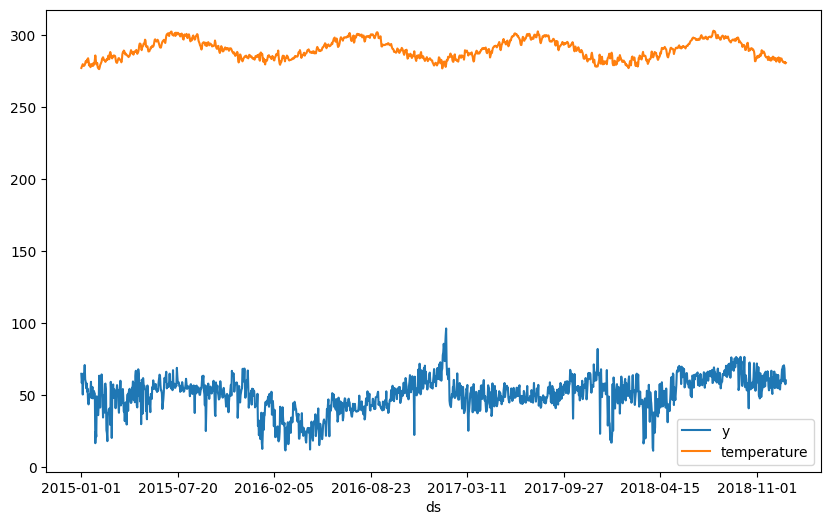

In [3]:
fig = df.plot(x="ds", y=["y", "temperature"], figsize=(10, 6))

In [ ]:
from neuralprophet import NeuralProphet, set_log_level

# Disable logging messages unless there is an error
set_log_level("ERROR")

# Model and prediction
m = NeuralProphet(
    n_changepoints=10,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    n_lags=10,
)
m.set_plotting_backend("plotly-static")

# Add the new future regressor
m.add_future_regressor("temperature")

# Continue training the model and making a prediction
metrics = m.fit(df)
forecast = m.predict(df)
m.plot(forecast)

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:410: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




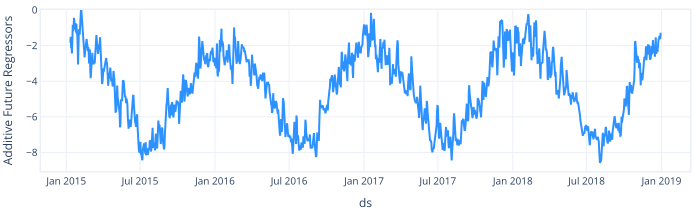

In [ ]:
m.plot_components(forecast, components=["future_regressors"])

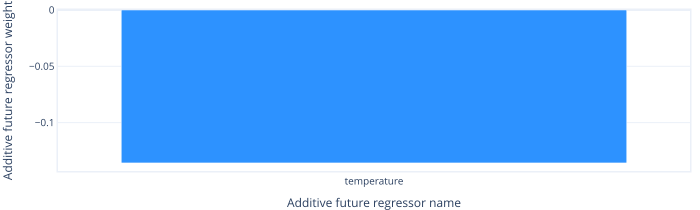

In [ ]:
m.plot_parameters(components=["future_regressors"])

In [ ]:
metrics

,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,0.289098,0.0,29.257826,33.907921,0.287358,0.0,0
1,0.158011,0.0,18.628887,23.100979,0.156898,0.0,1
2,0.090781,0.0,12.848584,16.343813,0.090381,0.0,2
3,0.058939,0.0,9.905992,12.653320,0.058978,0.0,3
4,0.044988,0.0,8.529761,10.988041,0.045566,0.0,4
...,...,...,...,...,...,...,...
95,0.016579,0.0,4.871693,6.530460,0.016657,0.0,95
96,0.016587,0.0,4.832102,6.448217,0.016437,0.0,96
97,0.016597,0.0,4.829254,6.516308,0.016436,0.0,97
98,0.016581,0.0,4.856742,6.487414,0.016543,0.0,98


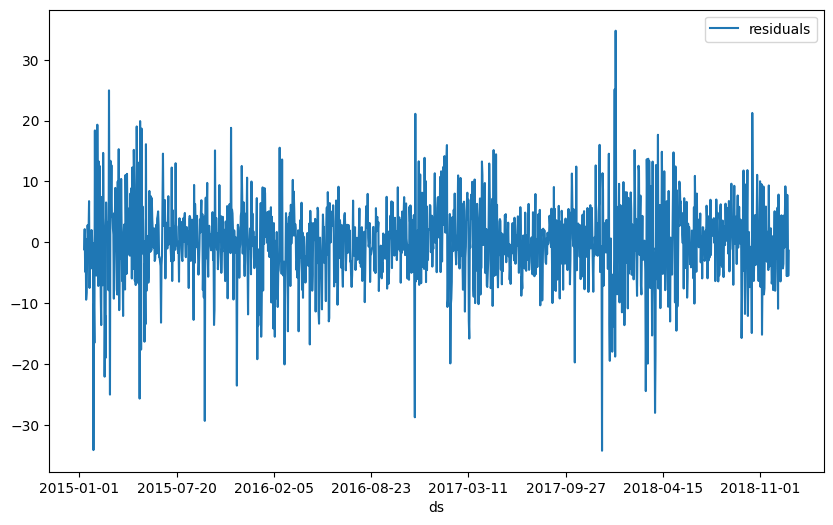

In [ ]:
df_residuals = pd.DataFrame({"ds": df["ds"], "residuals": df["y"] - forecast["yhat1"]})
fig = df_residuals.plot(x="ds", y="residuals", figsize=(10, 6))

d:\Neural_Networks\envs\timeseries\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.932% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils.return_df_in_or

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (37) is too small than the required number                     for the learning rate finder (227). The results might not be optimal.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\pytorch_lightning\utilities\data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\pytorch_lightning\utilities\data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 9. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

Finding best initial lr: 100%|██████████| 227/227 [00:02<00:00, 103.45it/s]


Training: |          | 0/? [00:36<?, ?it/s, v_num=36, train_loss=0.0192, reg_loss=0.000, MAE=4.940, RMSE=6.700, Loss=0.0193, RegLoss=0.000]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.667% of the data.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to 


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 156.35it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



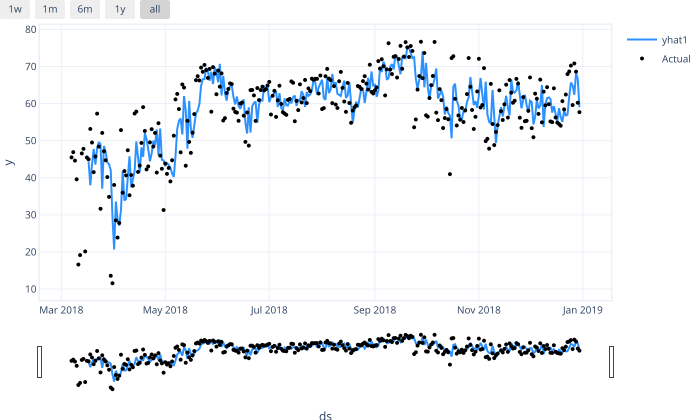

mean_absolute_percentage_error for last 60 days is:
0.10124991568862773


In [4]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from neuralprophet import NeuralProphet, set_log_level

# Model and prediction
m = NeuralProphet(
    n_changepoints=10,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    n_lags=10,
)
m.set_plotting_backend("plotly-static")

# Add the new future regressor
m.add_future_regressor("temperature")

ts_train, ts_test = m.split_df(df, valid_p = 0.2, local_split = True)
metrics = m.fit(ts_train)
forecast_test = m.predict(ts_test)
last_day = 60
m.plot(forecast_test)

print(f'mean_absolute_percentage_error for last {last_day} days is:')
print(mean_absolute_percentage_error(df.set_index('ds')['y'].iloc[-last_day:], forecast_test.set_index('ds')['yhat1'].iloc[-last_day:]))